**LoanTap** is a leading fintech company in India, renowned for providing flexible and innovative loan products to both individuals and businesses. With a customer-centric approach, LoanTap utilizes advanced technology to deliver seamless borrowing experiences, including personal loans, salary advances, and customizable EMI options. Their commitment to transparency, speed, and convenience has made them a trusted partner for borrowers seeking reliable financial solutions.

 - At the forefront of financial innovation, LoanTap is dedicated to offering personalized financial products tailored to the needs of millennials. Their forward-thinking strategy involves leveraging data science to refine and enhance the credit underwriting process.

 - The focus here is on the **Personal Loan** segment. By diving deep into the dataset, we can uncover valuable insights into borrower behavior, creditworthiness, and spending patterns. 

 - Analyzing this data will provide critical insights into the financial behaviors, risk factors, and repayment capabilities of borrowers, ultimately helping to optimize loan disbursal and strike a balance between customer outreach and effective risk management.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("LoanData.csv")
df

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."


In [3]:
df.shape

(396030, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [5]:
df.dtypes

loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,395754.0,53.791749,24.452193,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


In [7]:
df.describe(include='object').T

,count,unique,top,freq
term,396030,2,36 months,302005
grade,396030,7,B,116018
sub_grade,396030,35,B3,26655
emp_title,373103,173105,Teacher,4389
emp_length,377729,11,10+ years,126041
home_ownership,396030,6,MORTGAGE,198348
verification_status,396030,3,Verified,139563
issue_d,396030,115,Oct-2014,14846
loan_status,396030,2,Fully Paid,318357
purpose,396030,14,debt_consolidation,234507


In [8]:
df.isna().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

loan_amnt                 1397
term                         2
int_rate                   566
installment              55706
grade                        7
sub_grade                   35
emp_title               173105
emp_length                  11
home_ownership               6
annual_inc               27197
verification_status          3
issue_d                    115
loan_status                  2
purpose                     14
title                    48816
dti                       4262
earliest_cr_line           684
open_acc                    61
pub_rec                     20
revol_bal                55622
revol_util                1226
total_acc                  118
initial_list_status          2
application_type             3
mort_acc                    33
pub_rec_bankruptcies         9
address                 393700
dtype: int64

### Univariate Analysis

In [11]:
num_cols = ['loan_amnt','int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 
            'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

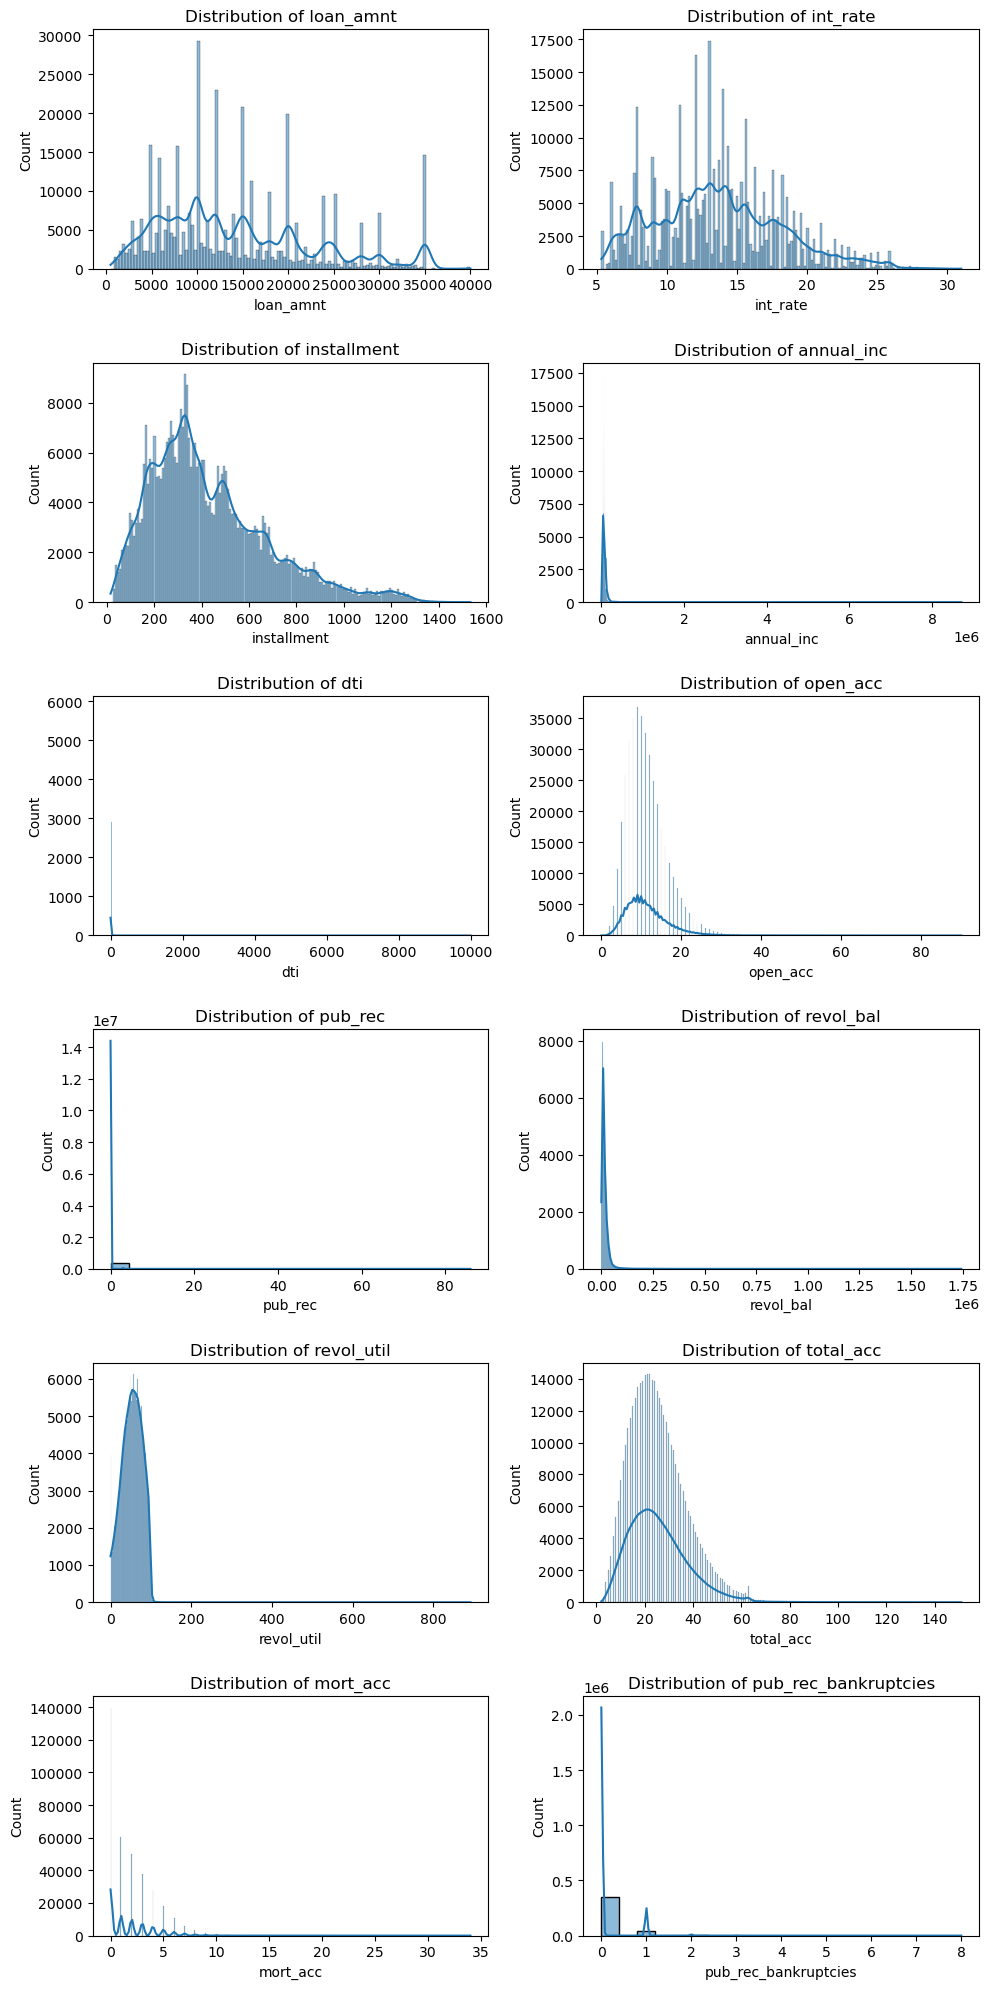

In [12]:
plt.figure(figsize=(10, 20))
for i, column in enumerate(num_cols, 1):
    plt.subplot(6, 2, i)  
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

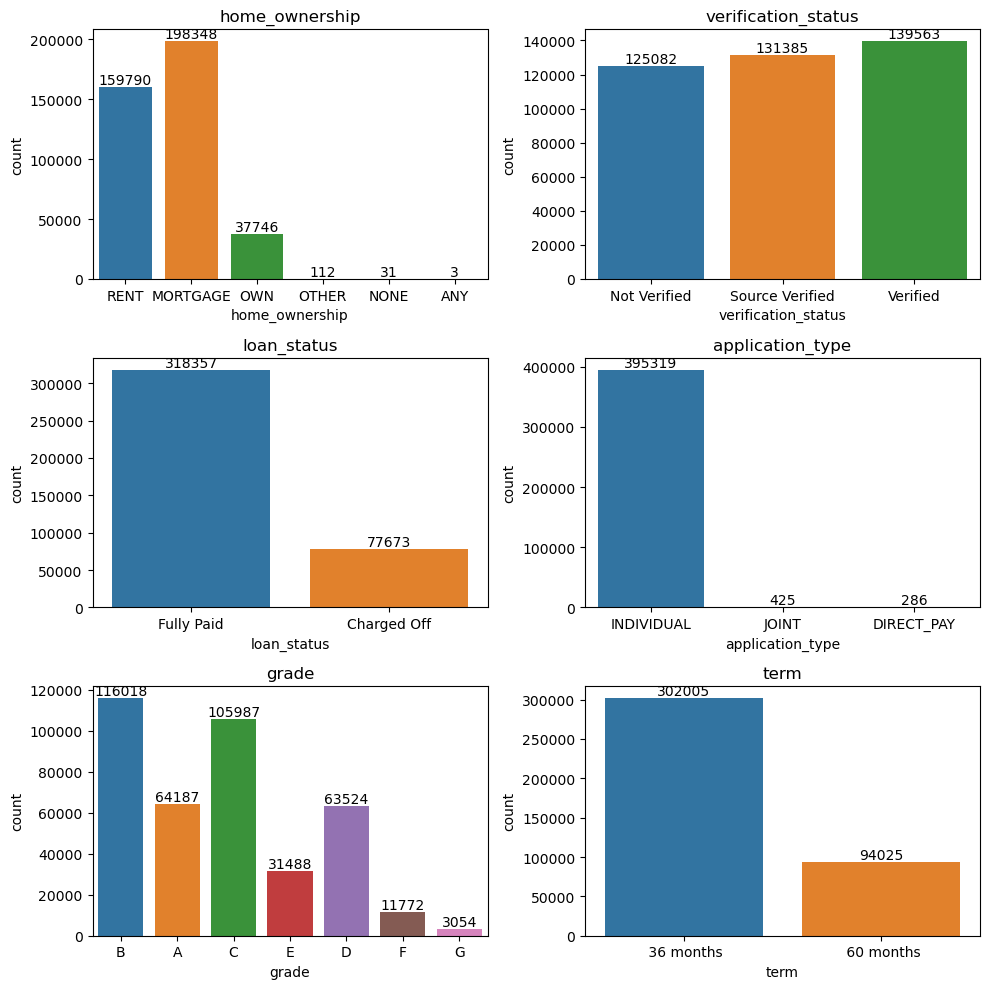

In [13]:
category_cols = ['home_ownership', 'verification_status', 'loan_status', 'application_type', 'grade', 'term']

plt.figure(figsize=(10, 10))
for i, column in enumerate(category_cols, 1):
    plt.subplot(3, 2, i) 
    ax = sns.countplot(data=df, x=column)
    plt.title(f'{column}')
    plt.xlabel(column)
    
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width() / 2,  
            p.get_height(),  
            int(p.get_height()),  
            ha='center',  
            va='bottom',  
            fontsize=10,  
            color='black'  
        )

plt.tight_layout()
plt.show()

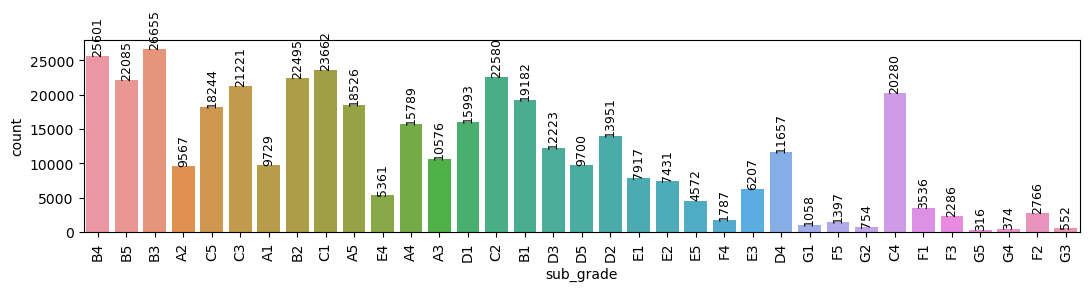

In [14]:
plt.figure(figsize=(11, 3))
ax = sns.countplot(data=df, x='sub_grade')

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2, 
        p.get_height(),  
        int(p.get_height()),  
        ha='center',  
        va='bottom',  
        fontsize=9,  
        color='black', 
        rotation=90 
    )

plt.tight_layout()  
plt.show()

### Bivariate Analysis

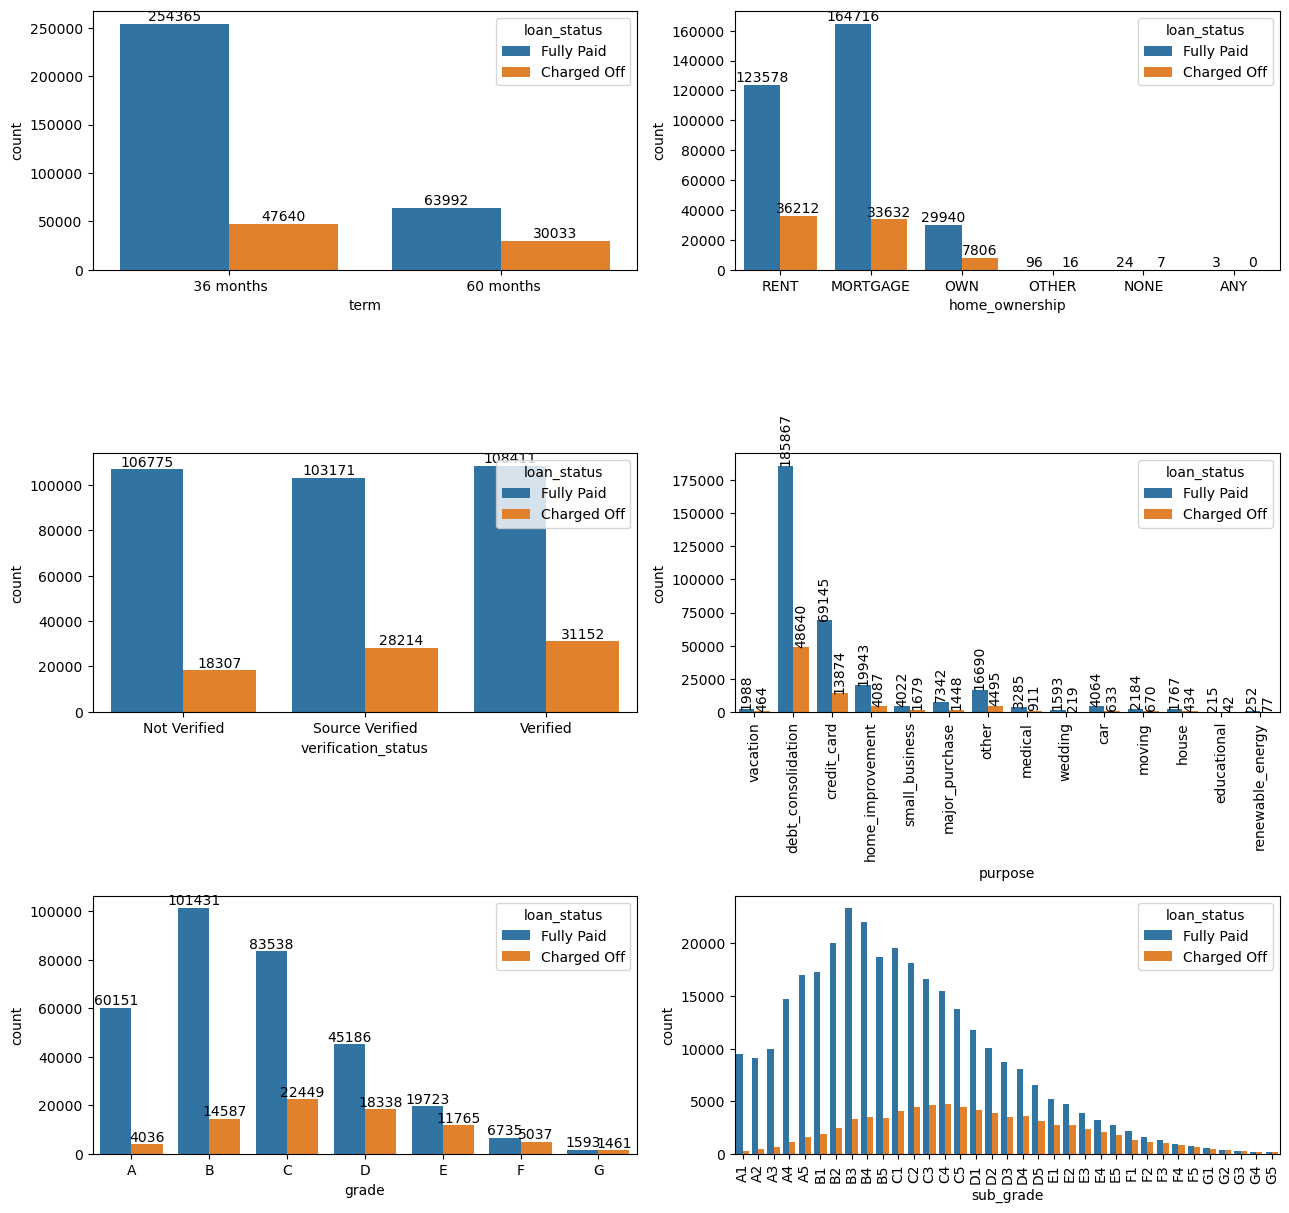

In [15]:
plt.figure(figsize=(13, 25))

plt.subplot(6, 2, 1)
ax = sns.countplot(x='term', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.subplot(6, 2, 2)
ax = sns.countplot(x='home_ownership', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.subplot(6, 2, 3)
ax = sns.countplot(x='verification_status', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.subplot(6, 2, 4)
ax = sns.countplot(x='purpose', data=df, hue='loan_status')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,  # Center of the bar
        p.get_height(),  # Height of the bar
        int(p.get_height()),  # Value to display
        ha='center',  # Center-aligned horizontally
        va='bottom',  # Bottom-aligned vertically
        fontsize=10,  # Font size
        color='black',  # Text color
        rotation=90  # Rotate text by 90 degrees
    )

plt.subplot(6, 2, 5)
grade = sorted(df.grade.unique().tolist())
ax = sns.countplot(x='grade', data=df, hue='loan_status', order=grade)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.subplot(6, 2, 6)
sub_grade = sorted(df.sub_grade.unique().tolist())
ax = sns.countplot(x='sub_grade', data=df, hue='loan_status', order=sub_grade)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

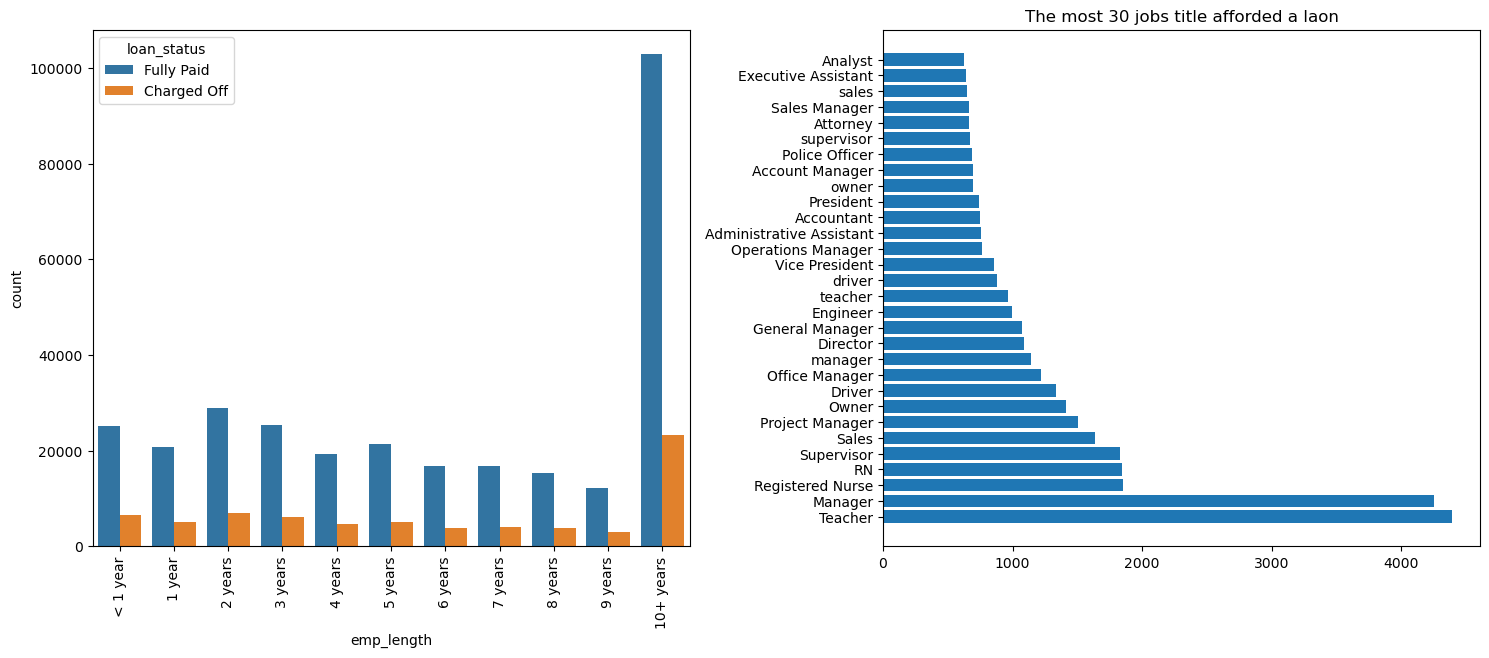

In [16]:
plt.figure(figsize=(15,12))

plt.subplot(2,2,1)
order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', 
          '6 years', '7 years', '8 years', '9 years', '10+ years',]
g=sns.countplot(x='emp_length',data=df,hue='loan_status',order=order)
g.set_xticklabels(g.get_xticklabels(),rotation=90)

plt.subplot(2,2,2)
plt.barh(df.emp_title.value_counts()[:30].index,df.emp_title.value_counts()[:30])
plt.title("The most 30 jobs title afforded a laon")
plt.tight_layout()

plt.show()

### Outlier Detection

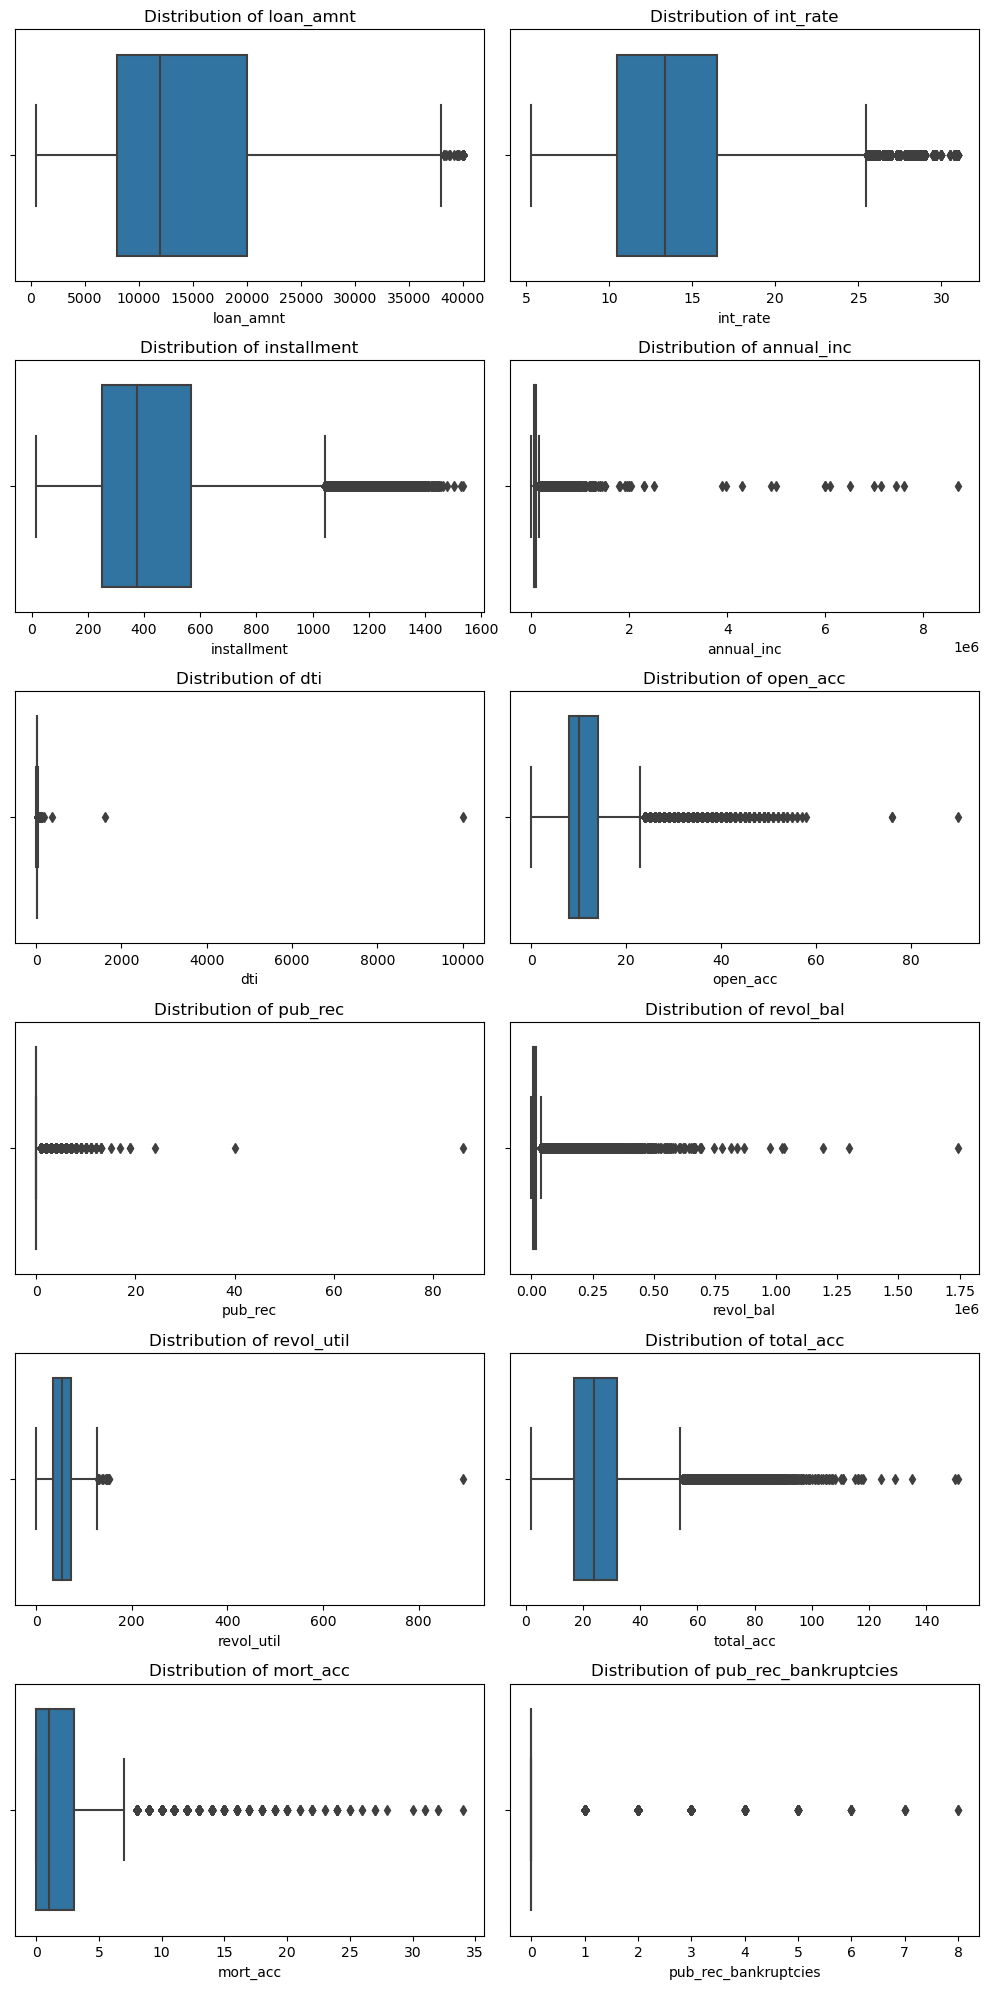

Summary Statistics for Each Column:

loan_amnt:
--------------------------------------------------
  Q1 (25th percentile): 8000.00
  Median (50th percentile): 12000.00
  Q3 (75th percentile): 20000.00
  Max Value: 40000.00
  Min Value: 500.00
**************************************************

int_rate:
--------------------------------------------------
  Q1 (25th percentile): 10.49
  Median (50th percentile): 13.33
  Q3 (75th percentile): 16.49
  Max Value: 30.99
  Min Value: 5.32
**************************************************

installment:
--------------------------------------------------
  Q1 (25th percentile): 250.33
  Median (50th percentile): 375.43
  Q3 (75th percentile): 567.30
  Max Value: 1533.81
  Min Value: 16.08
**************************************************

annual_inc:
--------------------------------------------------
  Q1 (25th percentile): 45000.00
  Median (50th percentile): 64000.00
  Q3 (75th percentile): 90000.00
  Max Value: 8706582.00
  Min Value: 0.00


In [17]:
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 
            'mort_acc', 'pub_rec_bankruptcies']

plt.figure(figsize=(10, 20))

for i, column in enumerate(num_cols, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(x=df[column])
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()


print("Summary Statistics for Each Column:")
print()

for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].median()  
    Q3 = df[column].quantile(0.75)
    min_val = df[column].min()
    max_val = df[column].max()
    print(f"{column}:")
    print("-"*50)
    print(f"  Q1 (25th percentile): {Q1:.2f}\n  Median (50th percentile): {Q2:.2f}\n  Q3 (75th percentile): {Q3:.2f}\n  Max Value: {max_val:.2f}\n  Min Value: {min_val:.2f}")
    print("*"*50)
    print()

In [18]:
from scipy.stats import skew

num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 
            'mort_acc', 'pub_rec_bankruptcies']

skewness_values = {column: df[column].skew() for column in num_cols}

sorted_skewness = dict(sorted(skewness_values.items(), key=lambda item: item[1], reverse=True))

skewness_df = pd.DataFrame(list(sorted_skewness.items()), columns=['Column', 'Skewness'])

skewness_df

,Column,Skewness
0,dti,431.051225
1,annual_inc,41.042725
2,pub_rec,16.576564
3,revol_bal,11.727515
4,pub_rec_bankruptcies,3.423440
5,mort_acc,1.600132
6,open_acc,1.213019
7,installment,0.983598
8,total_acc,0.864328
9,loan_amnt,0.777285


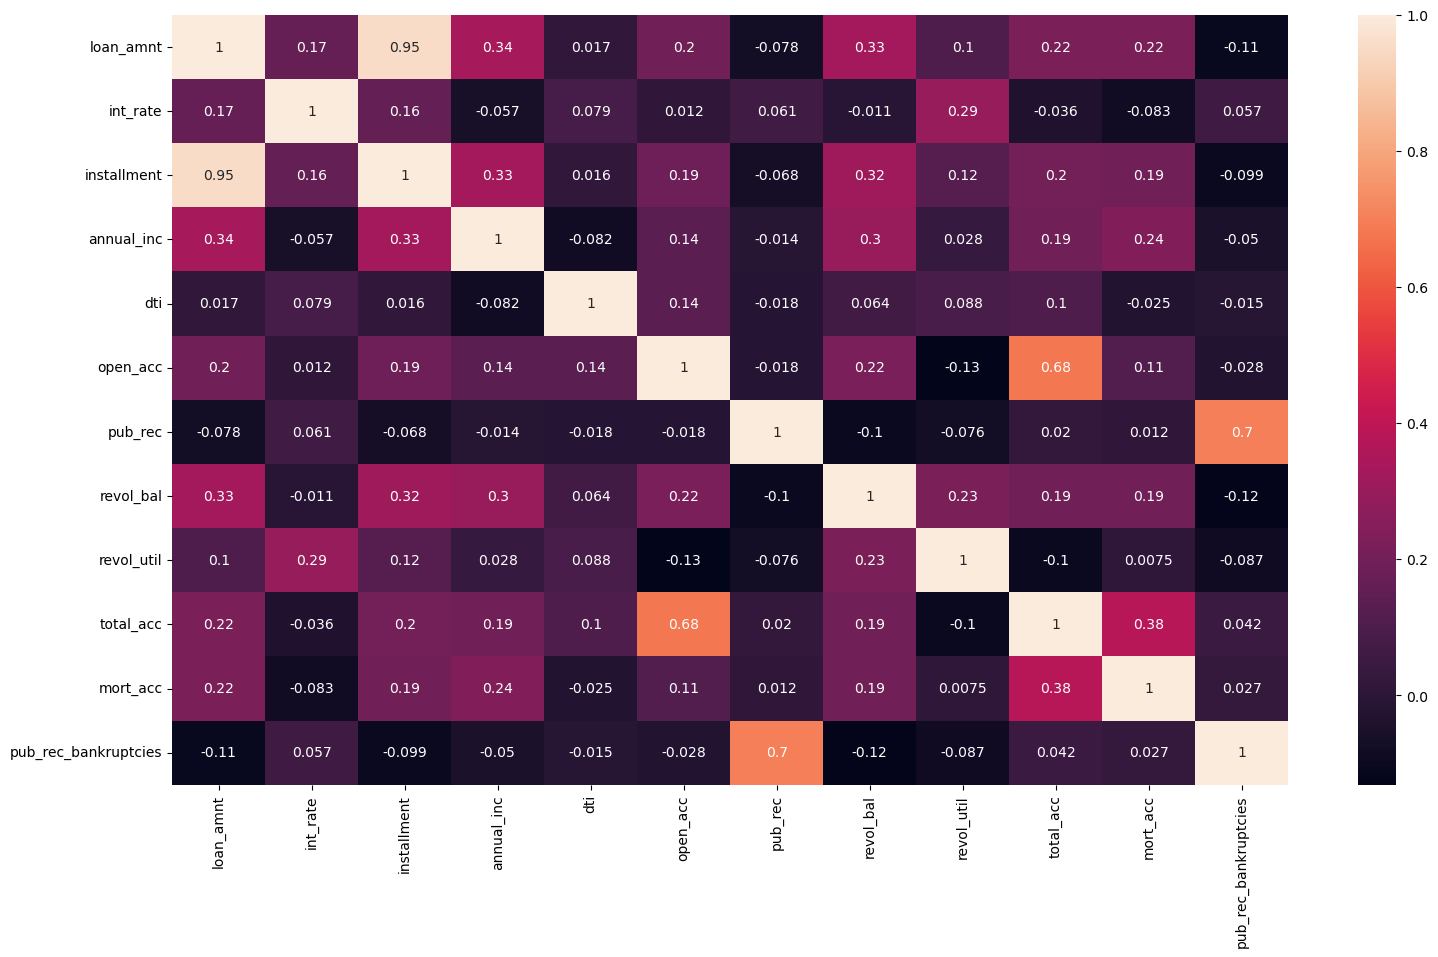

In [19]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.show()

##### Insights

We noticed almost perfect correlation between "loan_amnt" the "installment" feature.

installment: The monthly payment owed by the borrower if the loan originates.

loan_amnt: The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

##### Action

So, we can drop either one of those columns.

In [20]:
df.drop(columns=['installment'],axis=1,inplace=True)

### Data Preprocessing

In [21]:
df.duplicated().sum()

0

In [22]:
df.isna().sum()

loan_amnt                   0
term                        0
int_rate                    0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

In [23]:
df.emp_title.value_counts()

emp_title
Teacher                    4389
Manager                    4250
Registered Nurse           1856
RN                         1846
Supervisor                 1830
                           ... 
Postman                       1
McCarthy & Holthus, LLC       1
jp flooring                   1
Histology Technologist        1
Gracon Services, Inc          1
Name: count, Length: 173105, dtype: int64

In [24]:
df.emp_length.value_counts()

emp_length
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
9 years       15314
Name: count, dtype: int64

In [25]:
df.title.value_counts()

title
Debt consolidation            152472
Credit card refinancing        51487
Home improvement               15264
Other                          12930
Debt Consolidation             11608
                               ...  
Graduation/Travel Expenses         1
Daughter's Wedding Bill            1
gotta move                         1
creditcardrefi                     1
Toxic Debt Payoff                  1
Name: count, Length: 48816, dtype: int64

In [26]:
df.revol_util.value_counts()

revol_util
0.00      2213
53.00      752
60.00      739
61.00      734
55.00      730
          ... 
892.30       1
110.10       1
123.00       1
49.63        1
128.10       1
Name: count, Length: 1226, dtype: int64

In [27]:
df.mort_acc.value_counts()

mort_acc
0.0     139777
1.0      60416
2.0      49948
3.0      38049
4.0      27887
5.0      18194
6.0      11069
7.0       6052
8.0       3121
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
32.0         2
31.0         2
23.0         2
26.0         2
28.0         1
30.0         1
34.0         1
Name: count, dtype: int64

In [28]:
df.pub_rec_bankruptcies.value_counts()

pub_rec_bankruptcies
0.0    350380
1.0     42790
2.0      1847
3.0       351
4.0        82
5.0        32
6.0         7
7.0         4
8.0         2
Name: count, dtype: int64

In [29]:
df.emp_title.shape

(396030,)

In [30]:
import numpy as np
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer with strategy 'most_frequent'
imputer = SimpleImputer(strategy='most_frequent')

# List of columns to impute
columns_to_impute = ['emp_title', 'emp_length', 'title', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies']

# Iterate through columns and apply the imputer
for col in columns_to_impute:
    # Reshape column to 2D, apply imputer, and assign back to the DataFrame
    df[col] = imputer.fit_transform(df[col].values.reshape(-1, 1)).ravel()


In [31]:
df.isna().sum()

loan_amnt               0
term                    0
int_rate                0
grade                   0
sub_grade               0
emp_title               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
title                   0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
dtype: int64

In [32]:
def cap_outliers_with_clip(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)  
        Q3 = df[col].quantile(0.75) 
        IQR = Q3 - Q1               
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        df[col] = np.clip(df[col], lower_limit, upper_limit)

num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 
            'mort_acc', 'pub_rec_bankruptcies']

cap_outliers_with_clip(df, num_cols)

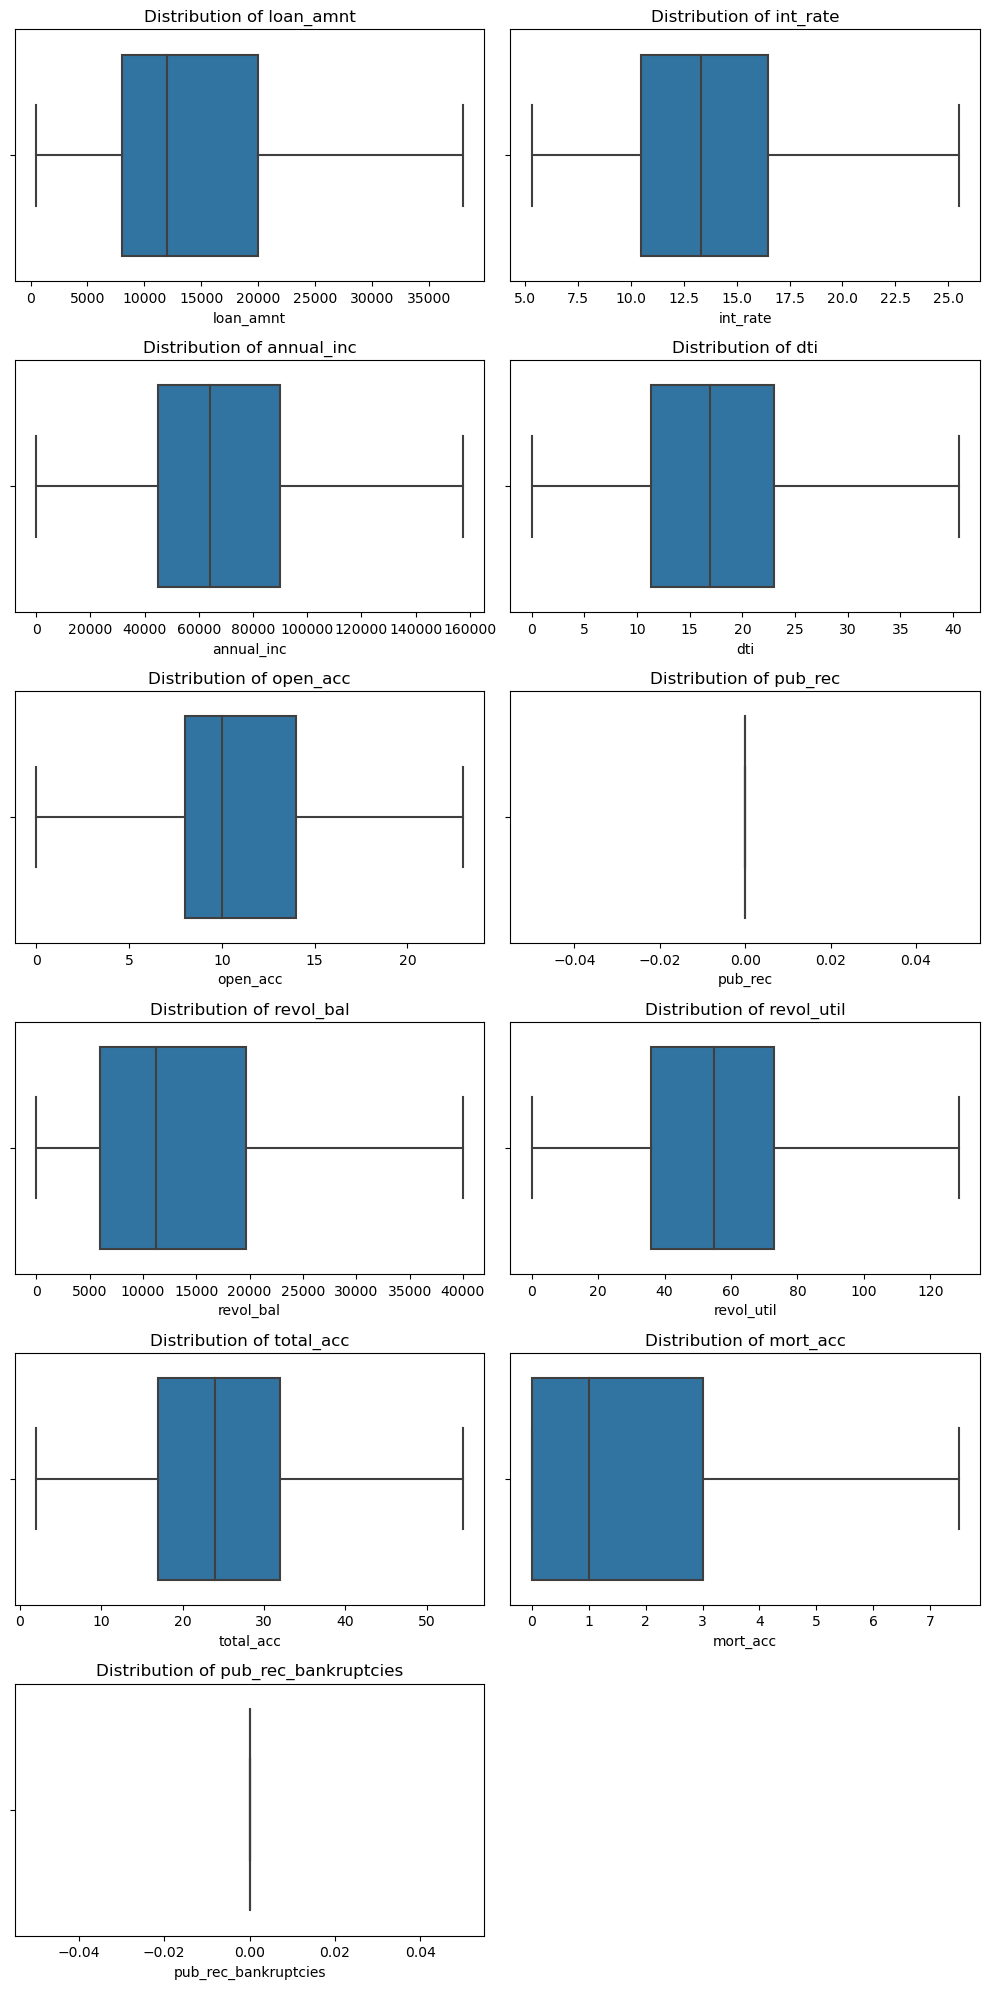

In [33]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 
            'mort_acc', 'pub_rec_bankruptcies']

plt.figure(figsize=(10, 20))

for i, column in enumerate(num_cols, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(x=df[column])
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

In [34]:
def pub_rec(number):
    if number == 0.0:
        return 0
    else:
        return 1
    
def mort_acc(number):
    if number == 0.0:
        return 0
    elif number >= 1.0:
        return 1
    else:
        return number
    
    
def pub_rec_bankruptcies(number):
    if number == 0.0:
        return 0
    elif number >= 1.0:
        return 1
    else:
        return number
    

df['pub_rec']=df.pub_rec.apply(pub_rec)
df['mort_acc']=df.mort_acc.apply(mort_acc)
df['pub_rec_bankruptcies']=df.pub_rec_bankruptcies.apply(pub_rec_bankruptcies)

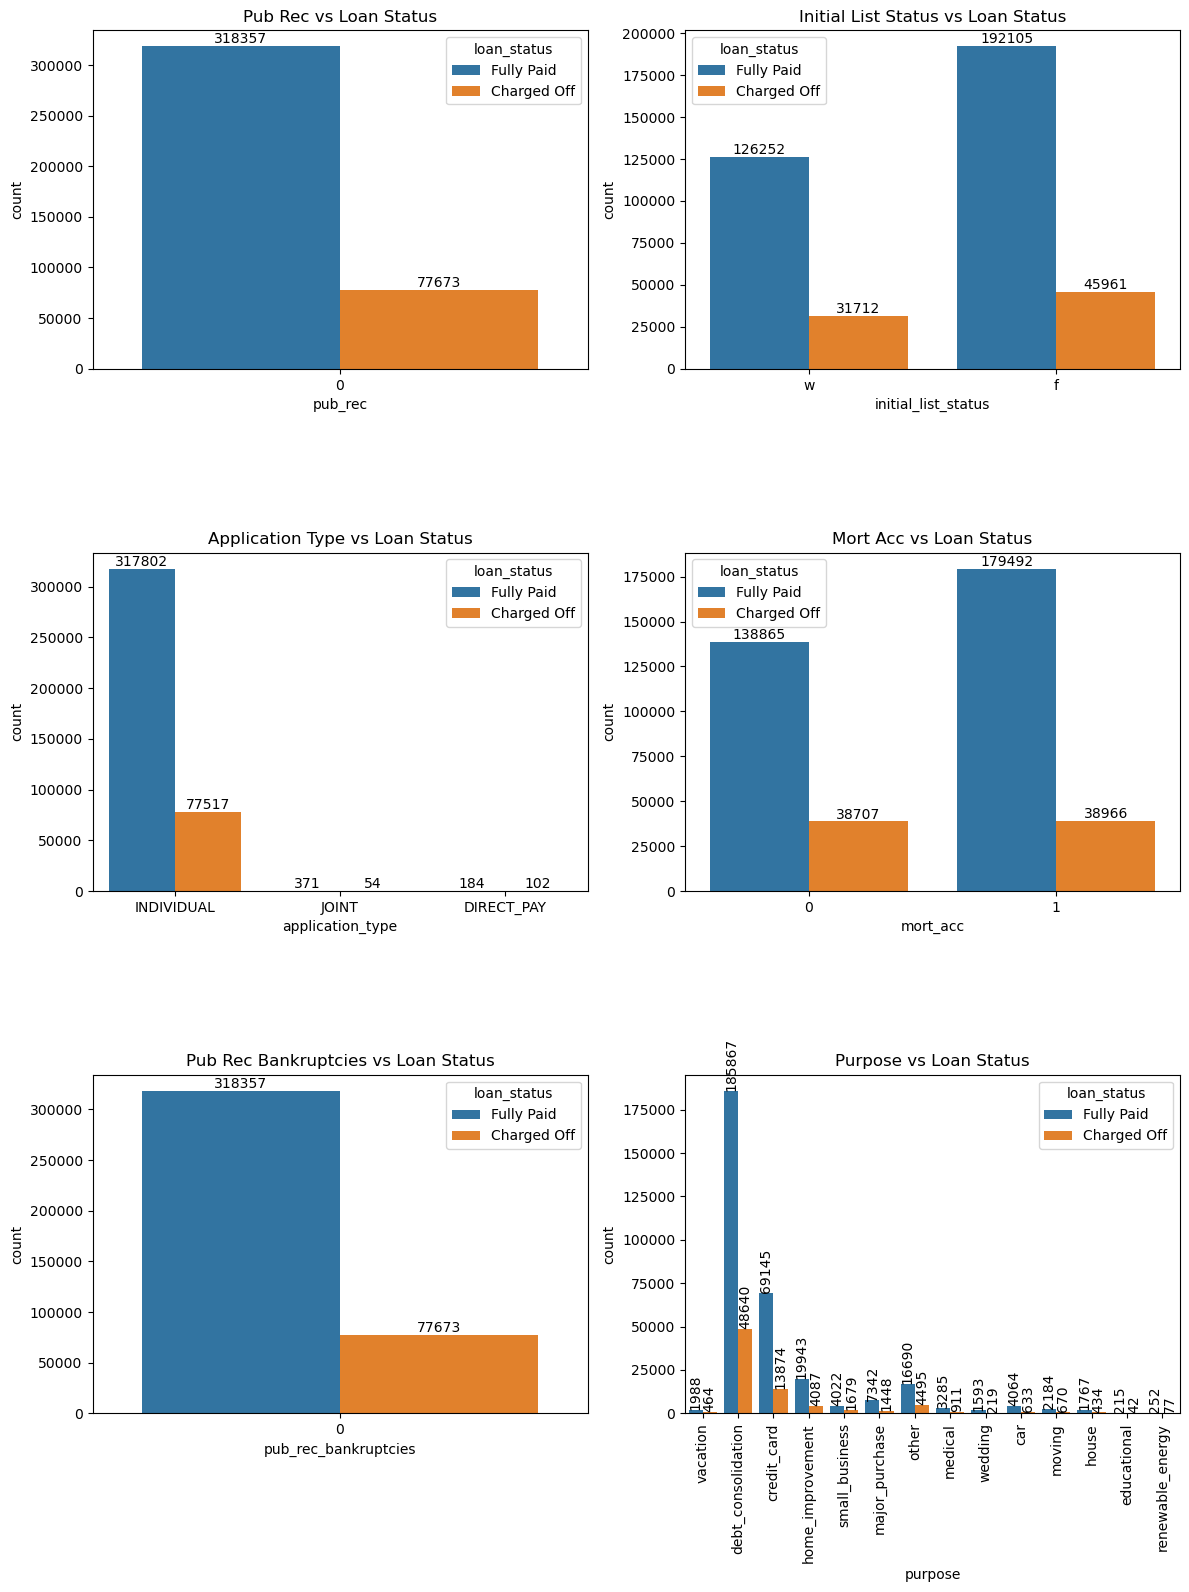

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 30))

plt.subplot(6, 2, 1)
ax = sns.countplot(x='pub_rec', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
ax.set_title('Pub Rec vs Loan Status')

plt.subplot(6, 2, 2)
ax = sns.countplot(x='initial_list_status', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
ax.set_title('Initial List Status vs Loan Status')

plt.subplot(6, 2, 3)
ax = sns.countplot(x='application_type', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
ax.set_title('Application Type vs Loan Status')

plt.subplot(6, 2, 4)
ax = sns.countplot(x='mort_acc', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
ax.set_title('Mort Acc vs Loan Status')

plt.subplot(6, 2, 5)
ax = sns.countplot(x='pub_rec_bankruptcies', data=df, hue='loan_status')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
ax.set_title('Pub Rec Bankruptcies vs Loan Status')

plt.subplot(6, 2, 6)
ax = sns.countplot(x='purpose', data=df, hue='loan_status')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        rotation = 90
    )
ax.set_title('Purpose vs Loan Status')

plt.tight_layout()
plt.show()

In [36]:
df['loan_status']=df.loan_status.map({'Fully Paid':1, 'Charged Off':0})
df['initial_list_status']=df.initial_list_status.map({'w':0, 'f':1})
df['term']=df.term.map({' 36 months':36, ' 60 months':60})

In [37]:
df['zip_code'] = df.address.apply(lambda x: x[-5:])
df['zip_code'].value_counts()

zip_code
70466    56985
30723    56546
22690    56527
48052    55917
00813    45824
29597    45471
05113    45402
11650    11226
93700    11151
86630    10981
Name: count, dtype: int64

In [38]:
df['state'] = df.address.apply(lambda x : x[-8:-6])
df['state'].value_counts()

state
AP    14308
AE    14157
AA    13919
NJ     7091
WI     7081
LA     7068
NV     7038
AK     7034
MA     7022
VA     7022
VT     7005
NY     7004
MS     7003
TX     7000
SC     6973
ME     6972
AR     6969
OH     6969
GA     6967
ID     6958
IN     6958
KS     6945
WV     6944
RI     6940
MO     6939
IL     6934
WY     6933
NE     6927
HI     6927
IA     6926
FL     6921
AZ     6918
CO     6914
OK     6911
CT     6904
MN     6904
NC     6901
OR     6898
CA     6898
AL     6898
MD     6896
WA     6895
UT     6887
SD     6887
MT     6883
DE     6874
TN     6869
ND     6858
MI     6854
DC     6842
NM     6842
PA     6825
NH     6818
KY     6800
Name: count, dtype: int64

In [39]:
df.drop(columns=['address'],axis=1,inplace=True)

In [40]:
df.emp_length.unique()

array(['10+ years', '4 years', '< 1 year', '6 years', '9 years',
       '2 years', '3 years', '8 years', '7 years', '5 years', '1 year'],
      dtype=object)

In [41]:
emp_length_mapping = {
    "10+ years": 10,
    "9 years": 9,
    "8 years": 8,
    "7 years": 7,
    "6 years": 6,
    "5 years": 5,
    "4 years": 4,
    "3 years": 3,
    "2 years": 2,
    "1 year": 1,
    "< 1 year": 0
}

df["emp_length_cat"] = df["emp_length"].map(emp_length_mapping)
df.drop(columns=['emp_length'],axis=1,inplace=True)

In [42]:
df['issue_month'] = df.issue_d.apply(lambda x : x[:3])
df['issue_year'] = df.issue_d.apply(lambda x:x[-4:])
df['earliest_cr_line_month'] = df.earliest_cr_line.apply(lambda x : x[:3])
df['earliest_cr_line_year'] = df.earliest_cr_line.apply(lambda x:x[-4:])

In [43]:
df.drop(columns=['issue_d','earliest_cr_line'],axis=1,inplace=True)

In [44]:
df

,loan_amnt,term,int_rate,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,loan_status,...,application_type,mort_acc,pub_rec_bankruptcies,zip_code,state,emp_length_cat,issue_month,issue_year,earliest_cr_line_month,earliest_cr_line_year
0,10000.0,36,11.44,B,B4,Marketing,RENT,117000.0,Not Verified,1,...,INDIVIDUAL,0,0,22690,OK,10,Jan,2015,Jun,1990
1,8000.0,36,11.99,B,B5,Credit analyst,MORTGAGE,65000.0,Not Verified,1,...,INDIVIDUAL,1,0,05113,SD,4,Jan,2015,Jul,2004
2,15600.0,36,10.49,B,B3,Statistician,RENT,43057.0,Source Verified,1,...,INDIVIDUAL,0,0,05113,WV,0,Jan,2015,Aug,2007
3,7200.0,36,6.49,A,A2,Client Advocate,RENT,54000.0,Not Verified,1,...,INDIVIDUAL,0,0,00813,MA,6,Nov,2014,Sep,2006
4,24375.0,60,17.27,C,C5,Destiny Management Inc.,MORTGAGE,55000.0,Verified,0,...,INDIVIDUAL,1,0,11650,VA,9,Apr,2013,Mar,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,B,B4,licensed bankere,RENT,40000.0,Source Verified,1,...,INDIVIDUAL,0,0,30723,DC,2,Oct,2015,Nov,2004
396026,21000.0,36,12.29,C,C1,Agent,MORTGAGE,110000.0,Source Verified,1,...,INDIVIDUAL,1,0,05113,LA,5,Feb,2015,Feb,2006
396027,5000.0,36,9.99,B,B1,City Carrier,RENT,56500.0,Verified,1,...,INDIVIDUAL,0,0,70466,NY,10,Oct,2013,Mar,1997
396028,21000.0,60,15.31,C,C2,"Gracon Services, Inc",MORTGAGE,64000.0,Verified,1,...,INDIVIDUAL,1,0,29597,FL,10,Aug,2012,Nov,1990


In [45]:
df['term'] = df['term'].astype('category')
df['loan_status'] = df['loan_status'].astype('category')
df['pub_rec'] = df['pub_rec'].astype('category')
df['initial_list_status'] = df['initial_list_status'].astype('category')
df['mort_acc'] = df['mort_acc'].astype('category')
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].astype('category')
df['emp_length_cat'] = df['emp_length_cat'].astype('category')

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to calculate VIF
def calculate_vif(data):
    X = data # Add constant for intercept term
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data


numeric_data = df.select_dtypes(include=[np.number])
# # Calculate VIF for numeric columns
calculate_vif(numeric_data)

,Variable,VIF
0,loan_amnt,6.234500
1,int_rate,10.266145
2,annual_inc,7.850393
3,dti,7.360714
4,open_acc,13.466892
5,revol_bal,5.095996
6,revol_util,7.966048
7,total_acc,11.608537


In [47]:
df.drop(columns=['open_acc','total_acc','int_rate'],axis=1,inplace=True)

In [48]:
from scipy.stats import chi2_contingency

categorical_columns = df.select_dtypes(exclude=[np.number]).drop(columns='loan_status').columns

target_column = 'loan_status'

results = []

for column in categorical_columns:
    contingency_table = pd.crosstab(df[column], df[target_column])  
    chi2, p, dof, _ = chi2_contingency(contingency_table)  
    
    results.append({
        "Column": column,
        "p-value": p
    })

pval_df = pd.DataFrame(results)

non_significant_columns = pval_df[pval_df["p-value"] > 0.05]

print("Non Significant Columns (p > 0.05):")
print(non_significant_columns)

Non Significant Columns (p > 0.05):
                    Column   p-value
3                emp_title  0.165425
7                    title  1.000000
8                  pub_rec  1.000000
12    pub_rec_bankruptcies  1.000000
14                   state  0.649503
18  earliest_cr_line_month  0.094411


In [49]:
df.drop(columns = non_significant_columns.Column.to_list(),inplace=True)

In [50]:
df.columns

Index(['loan_amnt', 'term', 'grade', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'loan_status', 'purpose', 'dti',
       'revol_bal', 'revol_util', 'initial_list_status', 'application_type',
       'mort_acc', 'zip_code', 'emp_length_cat', 'issue_month', 'issue_year',
       'earliest_cr_line_year'],
      dtype='object')

In [51]:
cols = df.select_dtypes(exclude=[np.number]).drop(columns='loan_status')

# Perform one-hot encoding on the selected columns
encoded_cols = pd.get_dummies(cols, drop_first=True)  # drop_first=True to avoid dummy variable trap

# Convert boolean values to integers (True -> 1, False -> 0)
encoded_cols = encoded_cols.astype(int)

# Drop the original categorical columns
df_dropped = df.drop(columns=cols.columns)

# Concatenate the one-hot encoded columns with the original DataFrame
df_encoded = pd.concat([df_dropped, encoded_cols], axis=1)
df_encoded

,loan_amnt,annual_inc,loan_status,dti,revol_bal,revol_util,term_60,grade_B,grade_C,grade_D,...,earliest_cr_line_year_2004,earliest_cr_line_year_2005,earliest_cr_line_year_2006,earliest_cr_line_year_2007,earliest_cr_line_year_2008,earliest_cr_line_year_2009,earliest_cr_line_year_2010,earliest_cr_line_year_2011,earliest_cr_line_year_2012,earliest_cr_line_year_2013
0,10000.0,117000.0,1,26.24,36369.0,41.8,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8000.0,65000.0,1,22.05,20131.0,53.3,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
2,15600.0,43057.0,1,12.79,11987.0,92.2,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
3,7200.0,54000.0,1,2.60,5472.0,21.5,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,24375.0,55000.0,0,33.95,24584.0,69.8,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,40000.0,1,15.63,1990.0,34.3,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
396026,21000.0,110000.0,1,21.45,40012.5,95.7,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
396027,5000.0,56500.0,1,17.56,32704.0,66.9,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
396028,21000.0,64000.0,1,15.88,15704.0,53.8,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns='loan_status')
y = df_encoded['loan_status']

Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.3,random_state=20)
Xtrain_col = Xtrain.columns

print(Xtrain.shape)
print(Xtest.shape)

(277221, 173)
(118809, 173)


#### Logistic Regression

In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.fit_transform(Xtest)
Xtrain = pd.DataFrame(Xtrain, columns=X.columns)
Xtest = pd.DataFrame(Xtest, columns=X.columns)

In [54]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
model.fit(Xtrain,ytrain)

LogisticRegression(max_iter=1000)

In [55]:
coefficients = model.coef_[0]

feature_coeff_pairs = list(zip(Xtrain_col, coefficients))

sorted_features = sorted(feature_coeff_pairs, key=lambda x: abs(x[1]), reverse=True)

print("Feature Name and Coefficients sorted by Absolute Value:")
for feature, coef in sorted_features:
    print(f"{feature}: {coef}")


Feature Name and Coefficients sorted by Absolute Value:
zip_code_11650: -12.829930549345999
zip_code_93700: -12.823424700394794
zip_code_86630: -12.798380895754173
zip_code_48052: -5.028906044457225
zip_code_30723: -4.992237743449344
zip_code_70466: -4.9843631245375395
zip_code_22690: -4.975065994998401
zip_code_29597: 2.913216962188231
zip_code_05113: 2.908049924209123
grade_G: -2.0145606186924345
grade_F: -1.9032052411141767
grade_E: -1.7751670234291497
grade_D: -1.5928598692889246
grade_C: -1.3434946452668979
earliest_cr_line_year_1960: -1.32249453196794
application_type_JOINT: 1.0073207779403326
earliest_cr_line_year_1964: -0.978924582212131
grade_B: -0.9425557719500276
annual_inc: 0.9130873541003154
dti: -0.9060316694265281
earliest_cr_line_year_2013: 0.817561976158542
sub_grade_A5: -0.8112421382239875
earliest_cr_line_year_1956: -0.7616144224819953
earliest_cr_line_year_1955: -0.7528449198749513
earliest_cr_line_year_1954: 0.7211506989818591
purpose_small_business: -0.63864141961

In [56]:
model.score(Xtest,ytest)

0.8908500197796463

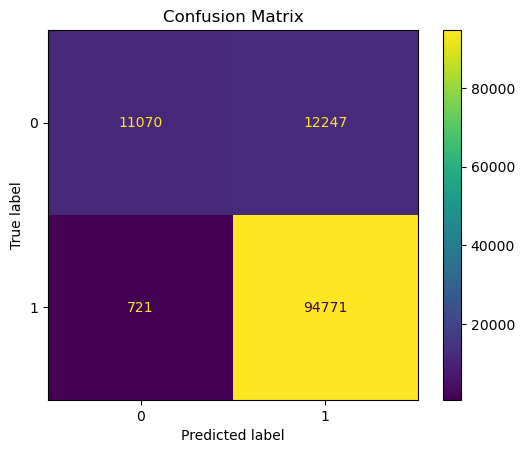

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ypred = model.predict(Xtest)
conf_matrix = confusion_matrix(ytest, ypred)


disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.94      0.47      0.63     23317
           1       0.89      0.99      0.94     95492

    accuracy                           0.89    118809
   macro avg       0.91      0.73      0.78    118809
weighted avg       0.90      0.89      0.88    118809



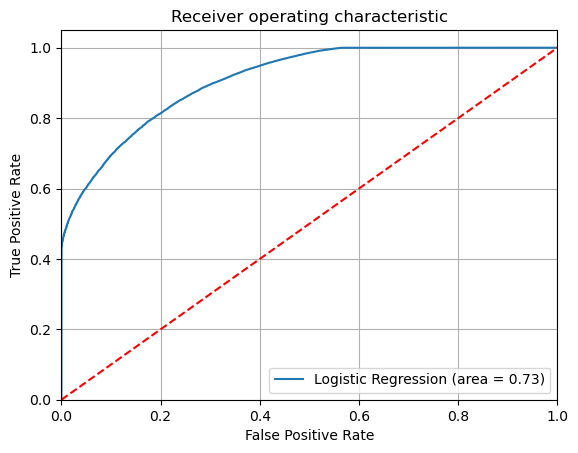

In [59]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


logit_roc_auc = roc_auc_score(ytest, model.predict(Xtest))

fpr, tpr, thresholds = roc_curve(ytest, model.predict_proba(Xtest)[:,1])


plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.grid()
plt.show()

#### Trade-off in Performance: 

The ROC curve area, representing model performance, is 73%. This indicates that the model effectively distinguishes between classes 72% of the time.

Ideally, we aim for a higher True Positive Rate (TPR) and a lower False Positive Rate (FPR) to ensure accurate predictions.

The ROC curve illustrates that as True Positives increase, there's a simultaneous increase in False Positives.

**Misclassification:** This trade-off implies that while identifying more Fully Paid customers, there's a heightened risk of misclassifying Charged Off customers as Fully Paid, potentially leading to Non-Performing Assets (NPAs).

These points emphasize the need to mitigate this risk:

Reducing FPR while maintaining TPR is crucial to minimize misclassifications and associated risks.
By shifting False Positives towards the left on the ROC curve, the model's overall performance, as measured by AUC, can improve.
This improvement in AUC relies on maintaining a high True Positive Rate while reducing False Positives.

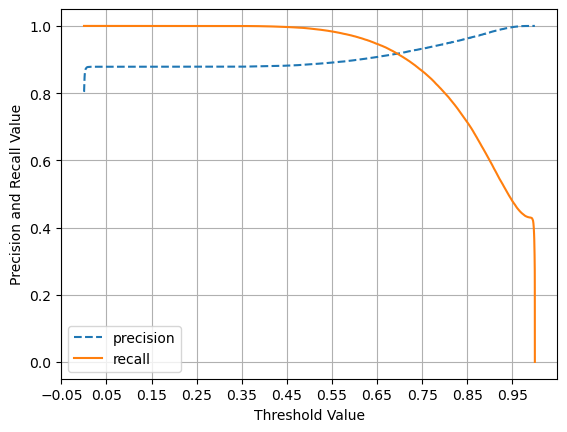

In [60]:
precisions, recalls, thresholds = precision_recall_curve(ytest, model.predict_proba(Xtest)[:, 1])

threshold_boundary = thresholds.shape[0]

# Plot precision
plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')

# Plot recall
plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1), 2))

plt.xlabel('Threshold Value')
plt.ylabel('Precision and Recall Value')
plt.legend()
plt.grid()
plt.show()

The Area Under the Curve (AUC) for the precision-recall curve is 0.975. This high AUC value suggests that the model achieves excellent performance in distinguishing between positive and negative classes, showcasing strong precision-recall characteristics.
**Precision-Recall Curve Superiority:** Precision-recall curves are pivotal, especially in imbalanced datasets, focusing on accurate predictions of the relevant class (Class 1 - Fully paid in this case).

**Irrelevance of True Negatives:** Precision and recall computations disregard true negatives, simplifying focus to the correct prediction of Fully Paid customers.

**AUC Strengthens Model Evaluation:** A high AUC (97.5%) underscores the model's robustness in distinguishing between classes, indicating its efficacy.

**Precision Enhancement Priority:** Optimal model refinement centers on elevating precision by minimizing False Positives, vital for improving overall performance and mitigating risks.

### Q1. What percentage of customers have fully paid their Loan Amount?

In [61]:
df.loan_status.value_counts(normalize=True)*100

loan_status
1    80.387092
0    19.612908
Name: proportion, dtype: float64

**Target variable distribution is 80%-20%. Data is significantly imbalance**

### Q2. Comment about the correlation between Loan Amount and Installment features.

  From the heat map analysis above we could see 0.95 correlation is there

### Q3. The majority of people have home ownership as

In [62]:
df['home_ownership'].value_counts(normalize=True)*100

home_ownership
MORTGAGE    50.084085
RENT        40.347953
OWN          9.531096
OTHER        0.028281
NONE         0.007828
ANY          0.000758
Name: proportion, dtype: float64

- **Mortgage** holders comprise the majority with approximately 50.08%, indicating that a significant portion of individuals own homes through Mortgage agreements.
- **Renters** constitute a substantial portion, accounting for around 40.35% of home ownership types. This suggests a sizable demographic of individuals who opt for renting rather than owning a home

### Q4. People with grades ‘A’ are more likely to fully pay their loan. (T/F)

In [63]:
pd.crosstab(df['grade'],df['loan_status'], normalize = 'index')

loan_status,0,1
grade,,
A,0.062879,0.937121
B,0.125730,0.874270
C,0.211809,0.788191
D,0.288678,0.711322
E,0.373634,0.626366
F,0.427880,0.572120
G,0.478389,0.521611


**Yes Grade 'A'** borrowers demonstrate a significantly high likelihood of fully repaying their loans, with approximately 93.71% of loans being fully paid. This suggests that borrowers with the highest credit rating are more inclined to fulfill their loan obligations successfully.

### Q5. Name the top 2 afforded job titles.

From the above EDA we could see top 2 afforded job titles are 
  1. Teachers
  2. Managers

### Q6: Thinking from a bank's perspective, which metric should our primary focus be on..

- ROC AUC
- Precision
- Recall
- F1 Score

From a bank's perspective, minimizing risks and maximizing profitability are paramount. ROC AUC (Receiver Operating Characteristic Area Under Curve) is indeed a crucial metric because it encompasses both True Positive Rate (TPR) and False Positive Rate (FPR)

### Q7. How does the gap in precision and recall affect the bank?

- To comprehend the errors made by a model, it's crucial to evaluate both false positives and false negatives, which are gauged through metrics like recall and precision. When recall is low, it poses a significant risk for the bank.
- So, the gap between precision and recall will affect the bank. As the gap widens, there will be increase in incorrect predictions.
- Good precision means less False Positives. i.e. Less NPA loan accounts.
- Good recall means less False Negatives. i.e. not loosing on good customer

### Q8. Which were the features that heavily affected the outcome?

- **Address(Zipcode), Annual_Income, Grade seems** to be most important feature in our case.

- Loan duration term, Total Credit balance revol_bal, : Monthly debt vs. monthly income ratio dti, Interest int_rate also has high weights(coeffients) in the model .

### Q9. Will the results be affected by geographical location? (Yes/No)

Yes, we can see that zip_code (Address) is a very important feature so geographical location has impact on our result.

### Insights

- **Precision**: The precision score peaks at a threshold of 0.95, indicating the model’s strong ability to accurately predict whether a loan will be charged off. This high precision helps the business make more reliable decisions regarding loan default risks.
  
- **Recall**: The recall score is higher at smaller thresholds and plateaus after 0.95, showing that the model effectively identifies actual defaulters. This consistent performance beyond the 0.95 threshold indicates a stable detection of instances.

### Actionable Insights and Recommendations

- **Customer Payment Behavior**: 80% of customers have fully repaid their loans, while 20% are defaulters. This can inform business strategies aimed at targeting the defaulters more effectively.
  
- **Model Utility**: The trained model can be employed to predict whether a customer is likely to repay the loan or default. This will assist in proactive decision-making and risk management.

- **Model Performance**:  
  - The model achieves a **94% F1-score** for the negative class (Fully Paid), showing strong performance in classifying fully paid loans.
  - The model achieves a **62% F1-score** for the positive class (Charged off), indicating a moderate performance for identifying defaulters.
  
- **Cross-Validation & Testing**: The cross-validation accuracy is nearly identical to the test set accuracy, demonstrating the model's reliability on unseen data and suggesting that it is not overfitting.
  
- **Opportunities for Improvement**:  
  - The model can be enhanced by collecting more data, experimenting with more complex models, or fine-tuning the hyperparameters to improve its performance further.
  
- **ROC AUC Curve**: The ROC AUC score of 0.73 suggests that the model is correctly classifying about 73% of instances. While this is good, there’s still room for improvement in capturing more true positive instances.
  
- **Precision-Recall Trade-off**: The precision-recall curve shows the trade-off between precision and recall as the threshold is varied. Adjusting the threshold helps balance these metrics, and the ideal threshold will depend on the business application’s needs.
  
- **Effect of Balancing Dataset**: Balancing the dataset led to a significant improvement in both precision and recall for both classes, suggesting that it helped the model learn more effectively.

- **Logistic Regression Performance**: The logistic regression classifier achieved an **accuracy of 0.891** on the test set, which is decent and indicates that the model is performing well, rather than just being a result of chance.


### Business Recommendations
- Focus on maximizing the F1 score and area under the Precision-Recall Curve to effectively manage the precision-recall trade-off. This ensures identifying most defaulters while reducing false positives, enhancing risk management.
- Consider using more complex classifiers like Random Forests or XGBoost and perform hyperparameter tuning to enhance model performance and capture intricate relationships in the data.
- Employed stratified k-fold cross-validation to ensure representative distribution of minority class in each fold, providing reliable estimates of model performance.
- Scrutinize loans with lower grades more rigorously and consider adjusting interest rates to compensate for higher risk.
- Implement targeted strategies for high-risk zip codes, such as additional verification steps or higher interest rates.
- Evaluate small business loans with additional financial health checks and collateral requirements to mitigate default risk.
- By implementing these recommendations, LoanTap can enhance their loan approval process, minimize the risk of NPAs, and ensure sustainable growth and financial stability.
